In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import numpy as np
import scipy.stats as stats
import pandas as pd
import geopandas as gpd

In [ ]:
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/'

# Match Points Data to Grid 
visulisatoin: 
Natural Breaks (Jenks) > Logarithmic Scale	

- Natural Breaks (Jenks) – ✅✅ Best Choice:   
Groups data by minimizing within-class variance and maximizing between-class variance.  
Automatically finds the best way to separate zeros from small values and extreme outliers.  
Best for highly skewed data like yours, where most cells are zero, but some have significant waste.  
Verdict: Best for detecting natural groupings in your data. 🏆  

- Logarithmic Scale – ✅ Good  
Applies a log transformation, which helps spread out small values.  
Keeps zero separate, then scales non-zero values better.  
Best for cases where non-zero values range across orders of magnitude (e.g., 1, 10, 100, 1000).  
Verdict: Good for making non-zero variations visible while keeping zeros separate.  


## Points: 456433

In [ ]:
# Load points data from CSV
points_df = pd.read_csv(Base + "img/Combined_SVI.csv")  # Ensure your CSV has 'longitude' and 'latitude' columns
points_df = points_df[points_df['lat'] != 'NaN']
points_df = points_df.dropna(subset=['lat', 'lon'])  # Remove rows with NaN in lat or lon
points_df = points_df[(points_df['lat'] != 0) & (points_df['lon'] != 0)]  # Remove rows where lat or lon is 0
points_df

In [ ]:
# Convert DataFrame to GeoDataFrame
geometry = [Point(xy) for xy in zip(points_df["lon"], points_df["lat"])]
points_gdf = gpd.GeoDataFrame(points_df, geometry=geometry, crs="EPSG:4326")  # Set CRS (WGS84) / 32737
# points_gdf

# points_gdf[(points_gdf['Domestic'] == 'N') & (points_gdf['prediction'] == 'yes')]
points_gdf[points_gdf['Domestic'] == 'Y']  
# points_gdf['prediction'].unique()  

In [ ]:
points_gdf[points_gdf['Domestic'] == 'Y']

## Grid: 110463

In [ ]:
# Load grid data (can be GeoJSON, Shapefile, etc.)
grid_gdf = gpd.read_file(Base + "/Angela/grid-boundary-nairobi.gpkg")  # or use a Shapefile: "grid_data.shp"
grid_gdf.reset_index(drop=True, inplace=True)
grid_gdf

# Match
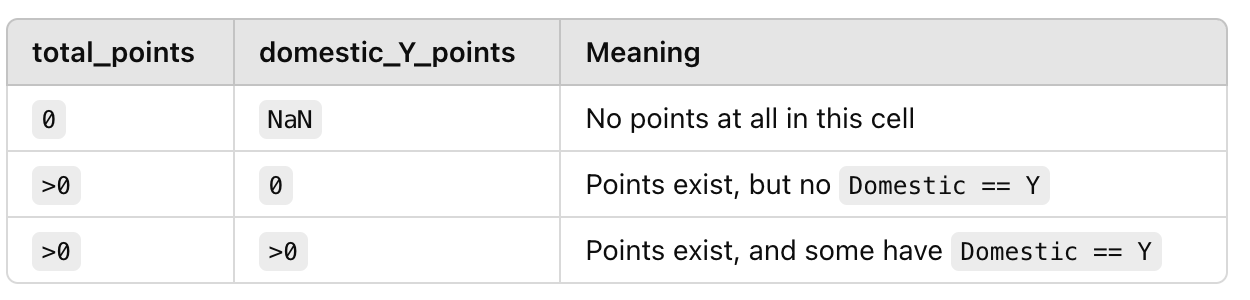

In [ ]:
# Perform a spatial join to match points to grid cells
matched_gdf = gpd.sjoin(points_gdf, grid_gdf, how="left", predicate="within")

# Aggregate counts per grid cell
summary_df = matched_gdf.groupby('index_right').agg(
    total_points=('img_name', 'count'),
    domestic_Y_points=('Domestic', lambda x: (x == "Y").sum())
).reset_index()
# summary_df

# Merge back to grid_gdf
grid_summary_gdf = grid_gdf.merge(summary_df, left_index=True, right_on='index_right', how='left')

# Set total_points to 0 where there are no matched points
grid_summary_gdf['total_points'] = grid_summary_gdf['total_points'].fillna(0)

# Set domestic_Y_points to "No_data" where there are no points in that cell
grid_summary_gdf['domestic_Y_points'] = np.where(grid_summary_gdf['total_points'] == 0, np.nan, grid_summary_gdf['domestic_Y_points'].fillna(0))
grid_summary_gdf

In [ ]:
print(grid_summary_gdf['domestic_Y_points'].sum())
# print(grid_summary_gdf['total_points'].sum())

In [ ]:
# Reset index
grid_summary_gdf = grid_summary_gdf.reset_index(drop=True)

# Calculate domestic waste ratio, avoiding division by zero
grid_summary_gdf['domestic_Y_ratio'] = np.where(
    grid_summary_gdf['total_points'] == 0, 
    np.nan,  # Set to NaN if no points exist in the cell
    grid_summary_gdf['domestic_Y_points'] / grid_summary_gdf['total_points']
)

grid_summary_gdf
# grid_summary_gdf['domestic_Y_ratio'].unique() # no ratio should be > 

In [ ]:
# grid_summary_gdf = grid_summary_gdf[grid_summary_gdf['total_points'] != 0 ].copy()
grid_summary_gdf.to_file(Base + "IDEAMaps/grid_waste_ratio.geojson", driver="GeoJSON")

# Combined approach
Empirical Bayes Smoothing adjusts for cells with very few images.  
IDW Interpolation fills in missing values based on nearby cells' ratios.  
The final result is stored in final_waste_ratio, which is:  
- Smoothed and statistically robust.
- Spatially continuous, avoiding sharp transitions.


In [ ]:
import numpy as np
import scipy.stats as stats
from scipy.spatial import cKDTree
from scipy.interpolate import griddata

In [ ]:
# Read the file into a GeoDataFrame
grid_summary_gdf = gpd.read_file(Base + "IDEAMaps/grid_waste_ratio.geojson")
grid_summary_gdf

## 🔹 Step 1: Compute Empirical Bayes Smoothed Waste Ratio

In [ ]:
# Data: observed waste detections and total images per grid cell
s = grid_summary_gdf['domestic_Y_points']  # Waste detections
n = grid_summary_gdf['total_points']  # Total images

# Compute global mean and variance for Empirical Bayes
mean_p = s.sum() / n.sum()  # Mean observed ratio
var_p = ((s / n - mean_p) ** 2).sum() / len(s)  # Variance of observed ratio

# Estimate Beta distribution priors
alpha_empirical = mean_p * ((mean_p * (1 - mean_p) / var_p) - 1)
beta_empirical = (1 - mean_p) * ((mean_p * (1 - mean_p) / var_p) - 1)

# Apply Empirical Bayes Smoothing
grid_summary_gdf['smoothed_waste_ratio'] = (s + alpha_empirical) / (n + alpha_empirical + beta_empirical)

# Set NaN where total_points == 0
grid_summary_gdf.loc[grid_summary_gdf['total_points'] == 0, 'smoothed_waste_ratio'] = np.nan
grid_summary_gdf

## 🔹 Step 2: Apply Inverse Distance Weighting (IDW) for Spatial Adjustment

In [ ]:
# Get coordinates of grid cells and their existing waste ratios
points = np.array([(geom.centroid.x, geom.centroid.y) for geom in grid_summary_gdf.geometry])
values = np.array(grid_summary_gdf['smoothed_waste_ratio'])

# Interpolate missing values using IDW
grid_summary_gdf['final_waste_ratio'] = griddata(points, values, points, method='linear')

# Fill remaining NaNs with the smoothed ratio (for cases where interpolation fails)
grid_summary_gdf['final_waste_ratio'] = grid_summary_gdf['final_waste_ratio'].fillna(grid_summary_gdf['smoothed_waste_ratio'])
grid_summary_gdf

In [ ]:
grid_No0_gdf = grid_summary_gdf[grid_summary_gdf['final_waste_ratio'].notna()]
grid_No0_gdf.to_file(Base + "IDEAMaps/grid_waste_SS_ratio.geojson", driver="GeoJSON")

# Add Focus group

In [ ]:
grid_summary_gdf

In [ ]:
# Load the GeoJSON file containing the area of interest
area_of_interest = gpd.read_file("/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/square.geojson")  # Replace with your actual GeoJSON file path

# Ensure both GeoDataFrames have the same CRS
grid_summary_gdf = grid_summary_gdf.to_crs(area_of_interest.crs)

# Perform spatial join to check if each row is within the area of interest
grid_summary_gdf['focused'] = grid_summary_gdf.geometry.within(area_of_interest.unary_union).astype(int)
grid_summary_gdf

# Form Final Dataset

In [ ]:
import numpy as np
import mapclassify as mc

final_df = grid_summary_gdf.loc[:, ['geometry', 'final_waste_ratio', 'focused']]
final_df = final_df.fillna(0)

# Apply Jenks Natural Breaks with 3 categories
classifier = mc.NaturalBreaks(final_df['final_waste_ratio'], k=3)
final_df['result'] = classifier.yb  # Categories start from 1

# final_df['result'].unique()
final_df

In [ ]:
# Reproject the geometry to EPSG:4326
final_df = final_df.to_crs(epsg=4326)

# Drop the index column (if it appears when saving)
final_df.reset_index(drop=True, inplace=True)
final_df

In [ ]:
final_df.to_file(Base + "IDEAMaps/waste_Nairobi_grid.geojson", driver="GeoJSON")

In [ ]:
# Ensure your data is a GeoDataFrame
# final_df = gpd.GeoDataFrame(final_df, geometry=final_df.geometry, crs="EPSG:4326")

# Extract bounding box (min/max coordinates)
final_df['lon_min'] = final_df.geometry.bounds['minx']
final_df['lat_min'] = final_df.geometry.bounds['miny']
final_df['lon_max'] = final_df.geometry.bounds['maxx']
final_df['lat_max'] = final_df.geometry.bounds['maxy']

# Compute the center latitude and longitude
final_df['latitude'] = (final_df['lat_min'] + final_df['lat_max']) / 2
final_df['longitude'] = (final_df['lon_min'] + final_df['lon_max']) / 2

# Select original columns + new ones
final_df = final_df.drop(columns=['geometry', 'final_waste_ratio'])  # Drop 'geometry' if not needed

final_df

In [ ]:
final_df['focused'].sum()

In [ ]:
final_df.to_csv(Base + "IDEAMaps/waste_Nairobi_outputs.csv")

这个waste_Nairobi_outputs是提交给IDEAMaps的csv, need to manuely delete first column

# Statistical Approaches
Great question! If a grid cell contains only one street view image, the ratio of waste (domestic_Y_ratio) can be misleading because it would be either 0% or 100%. This isn't statistically robust since one image is not enough to estimate the true probability of waste presence.

In [ ]:
grid_summary_gdf = grid_summary_gdf[grid_summary_gdf['total_points'] != 0 ].copy()
grid_summary_gdf

## 1. Bayesian Smoothing (Laplace Smoothing) - quick fix
This method adds pseudo-counts to stabilize the ratio, preventing extreme values (0% or 100%) when the sample size is small.  
- α is a smoothing parameter (e.g., 1 or 0.5).
- It prevents extreme 0 or 1 ratios for small samples.

Why This Works?  
If a grid has only one image:
- Without smoothing: Ratio = 0% or 100%.
- With smoothing: Ratio is pulled towards the mean (prior belief).  
As more images are available, the ratio converges to the true proportion.

In [ ]:
alpha = 1  # Smoothing factor

grid_summary_gdf["ratio_BSLS"] = (grid_summary_gdf["domestic_Y_points"] + alpha) / (grid_summary_gdf["total_points"] + 2 * alpha)
# grid_gdf
grid_summary_gdf['ratio_BSLS'].unique()

In [ ]:
# grid_summary_gdf.to_file(Base + "/IDEAMaps/Bayesian.geojson", driver="GeoJSON")

## 2. Confidence Intervals (Wilson Score Interval)
Instead of just reporting a single ratio, you can provide confidence intervals, which give a range where the true probability likely lies. Formula (Wilson Interval for a Proportion):  
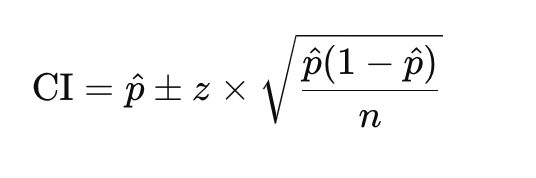  
Where:  
𝑝 = observed proportion.  
𝑧 = 1.96 for 95% confidence.  
𝑛 = number of images (total_points).  

Why This Works?  
Instead of reporting a single probability, we provide a range where the true ratio likely falls.  
If a grid has only 1 image, the confidence interval will be very wide, reflecting high uncertainty.

In [ ]:
from scipy.stats import norm
import numpy as np

z = norm.ppf(0.975)  # 95% confidence interval

grid_gdf["domestic_Y_ratio"] = np.where(
    grid_gdf["total_points"] > 0,
    grid_gdf["domestic_Y_points"] / grid_gdf["total_points"],
    np.nan
)

# Compute the confidence interval bounds
grid_gdf["ci_lower"] = np.where(
    grid_gdf["total_points"] > 0,
    grid_gdf["domestic_Y_ratio"] - z * np.sqrt(
        (grid_gdf["domestic_Y_ratio"] * (1 - grid_gdf["domestic_Y_ratio"])) / grid_gdf["total_points"]
    ),
    np.nan
)

grid_gdf["ci_upper"] = np.where(
    grid_gdf["total_points"] > 0,
    grid_gdf["domestic_Y_ratio"] + z * np.sqrt(
        (grid_gdf["domestic_Y_ratio"] * (1 - grid_gdf["domestic_Y_ratio"])) / grid_gdf["total_points"]
    ),
    np.nan
)
grid_gdf

In [ ]:
grid_gdf.to_file("/Users/wenlanzhang/Downloads/processed_data.geojson", driver="GeoJSON")

## Bayesian Smoothing (Empirical Bayes Estimation)
- Instead of using raw proportions, Bayesian Smoothing "shrinks" extreme ratios towards the mean, especially in areas with few images.
- This avoids over-representing places with only 1 or 2 images.
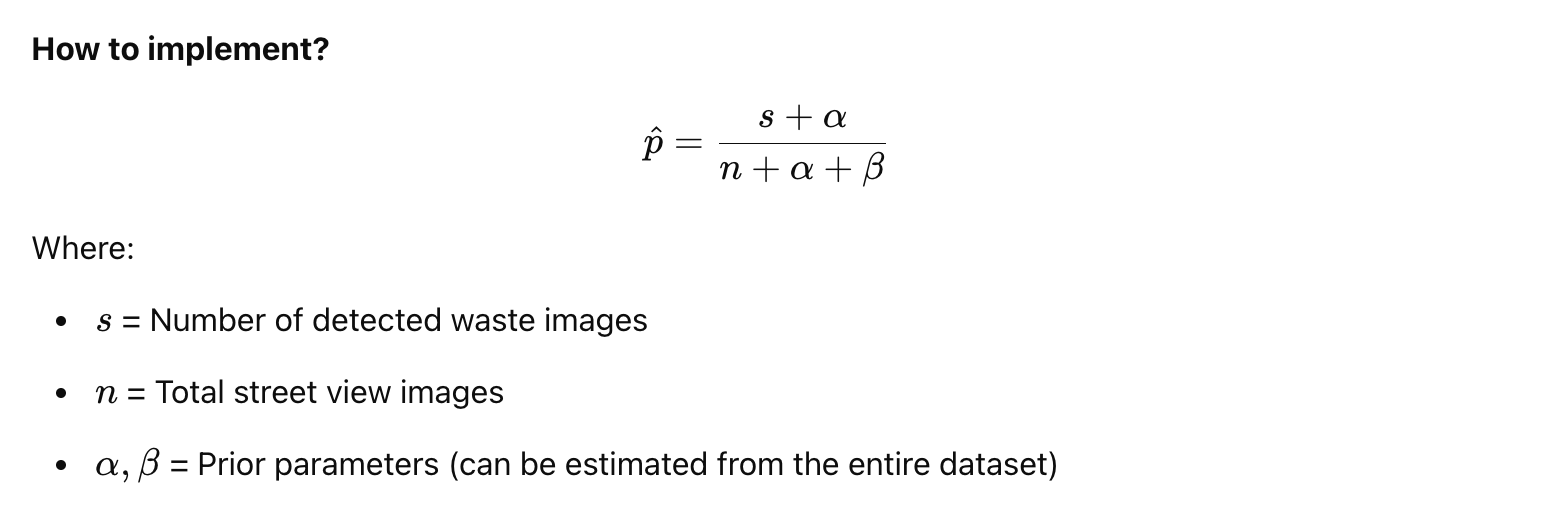  
Pros:  
✅ Avoids extreme values in areas with very few images.  
✅ More reliable in low-data regions.  

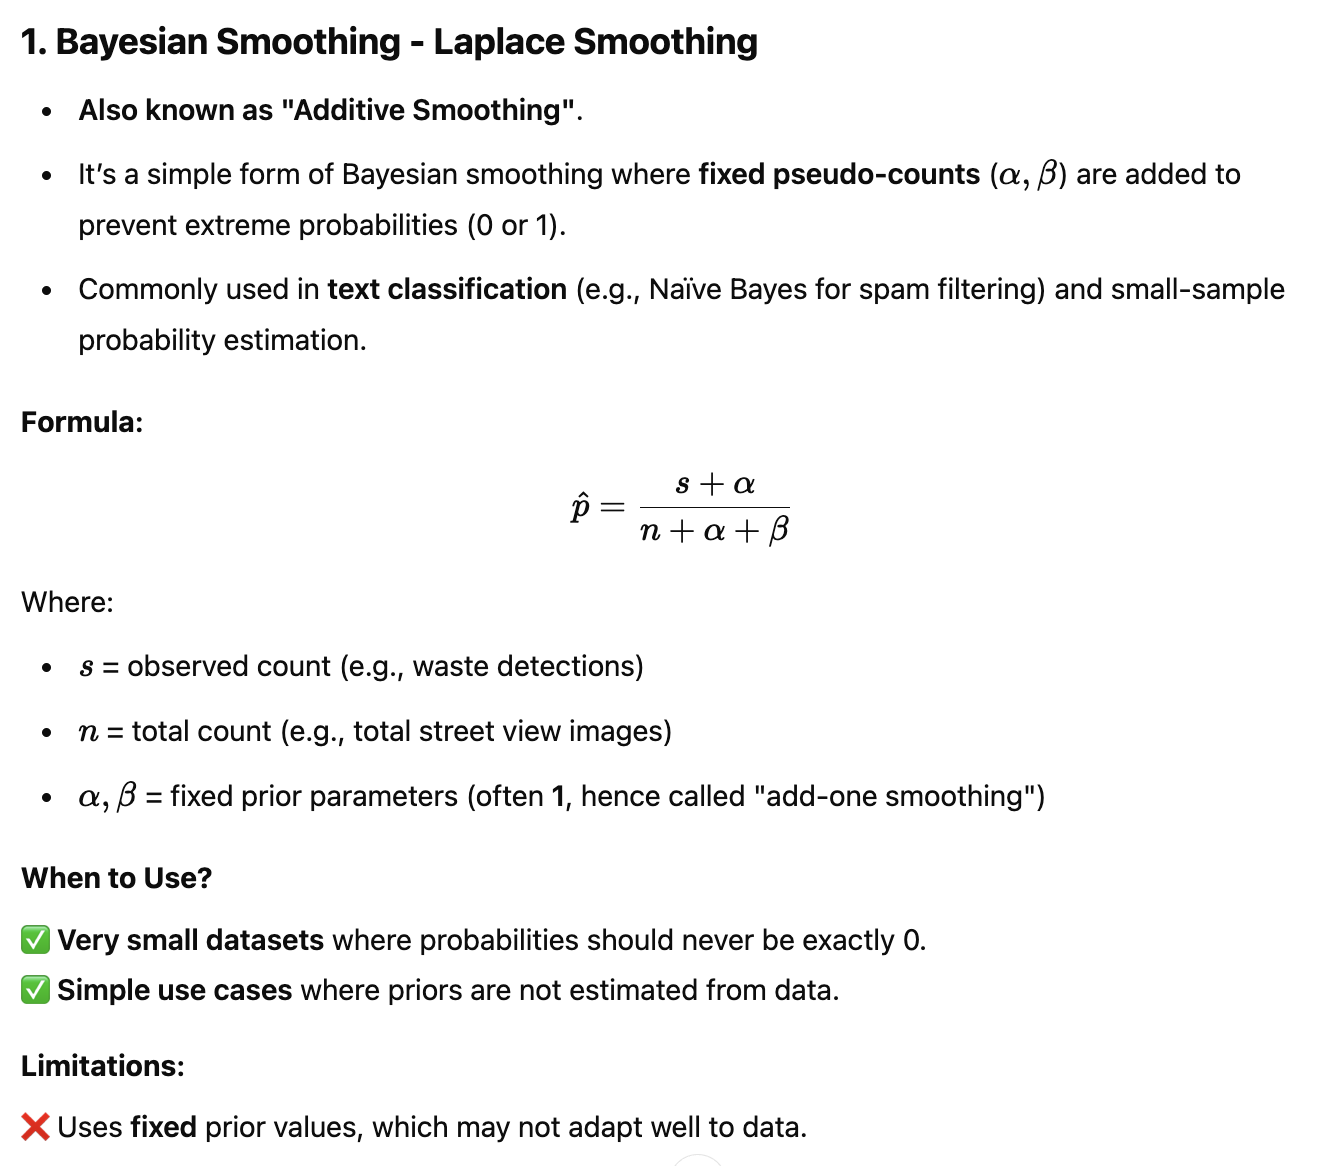
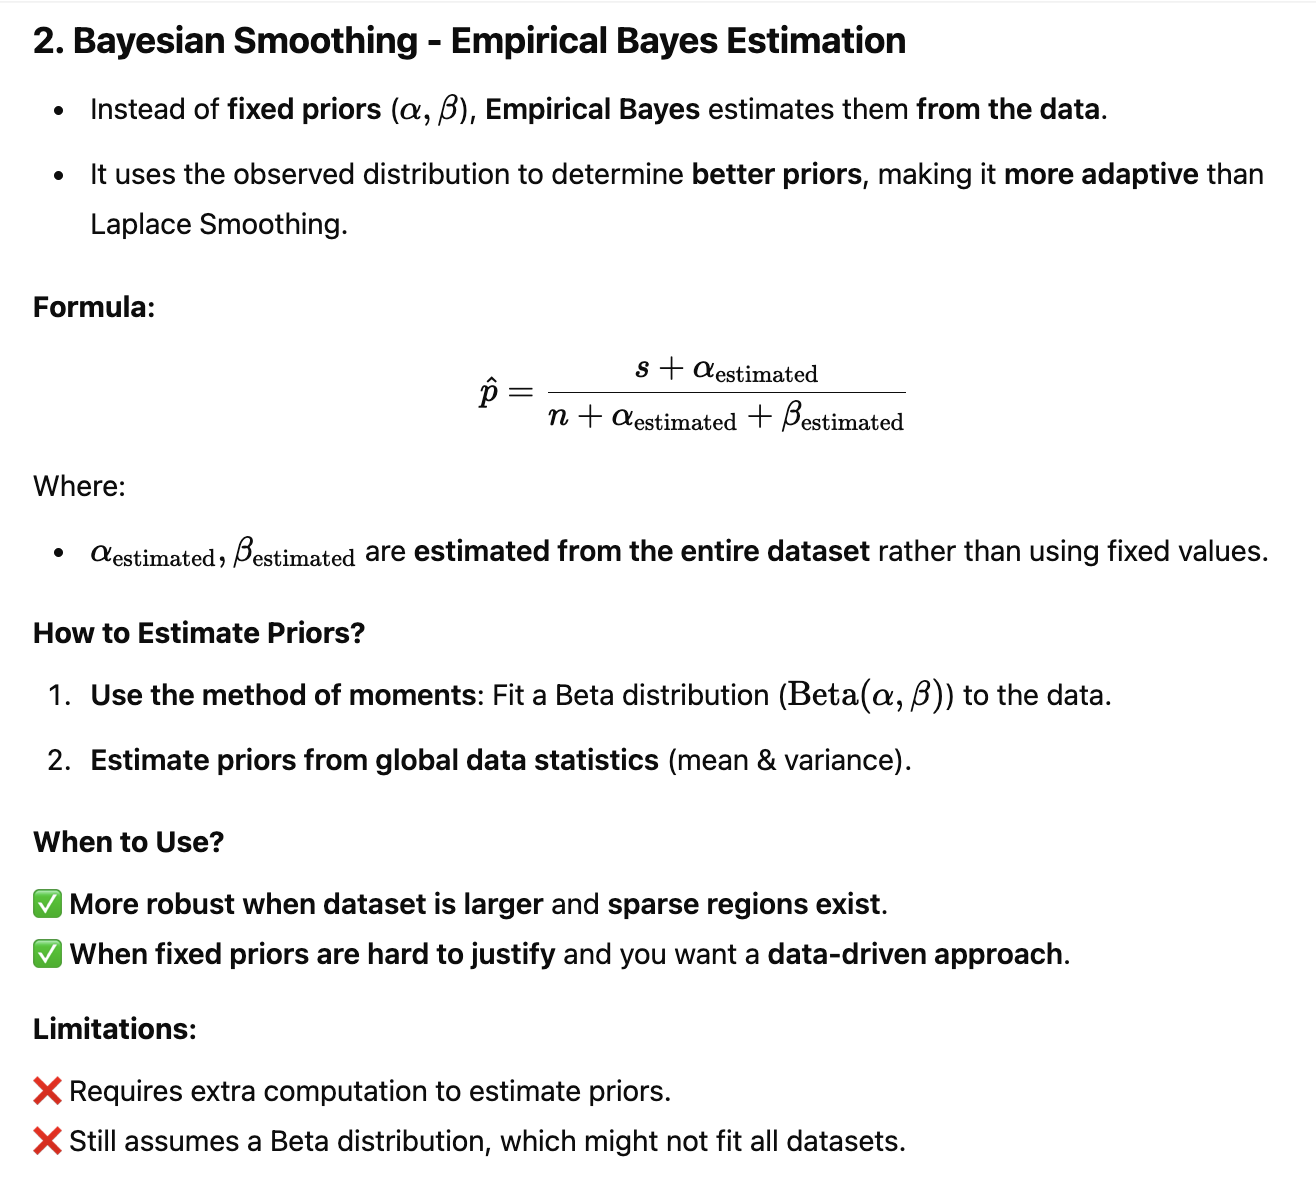
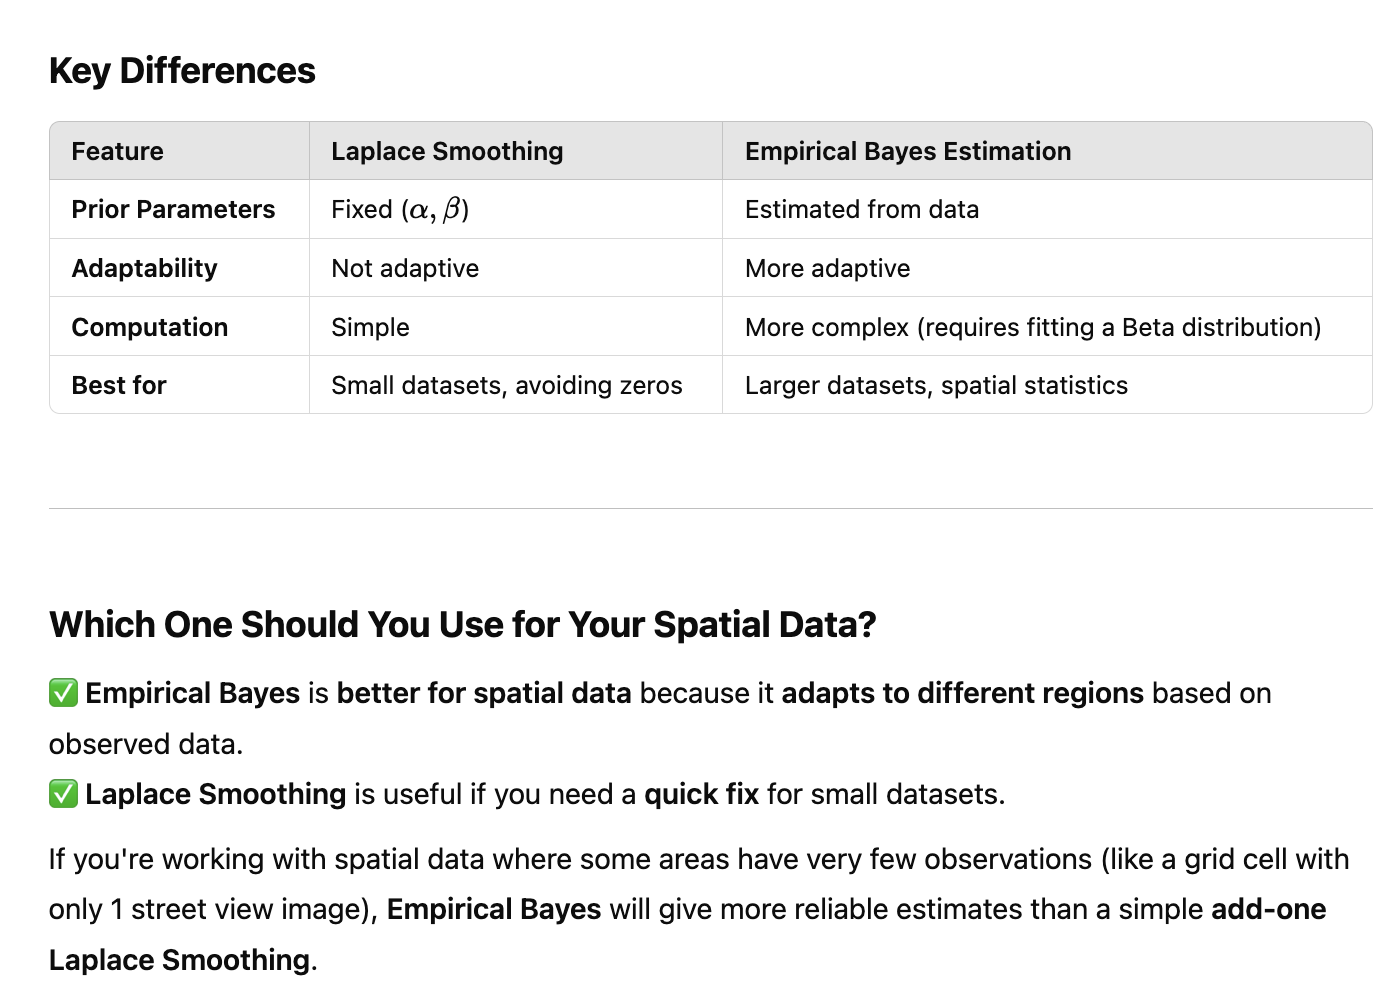
Final Recommendation：
Use Empirical Bayes 🏆 if you have spatial data and want more statistically meaningful estimates.  
Use Laplace Smoothing if you just need a quick fix for small datasets.  


In [ ]:
# Compute prior mean and variance from all data
alpha_prior = 1  # Prior success (waste detected)
beta_prior = 5   # Prior failure (no waste detected)

# Apply Bayesian Smoothing
grid_summary_gdf['ratio_BSEBE'] = (grid_summary_gdf['domestic_Y_points'] + alpha_prior) / \
                                           (grid_summary_gdf['total_points'] + alpha_prior + beta_prior)
grid_summary_gdf

## Weighted Average with Nearby Cells
- Instead of relying only on the cell's ratio, adjust it using a weighted average with neighboring cells.
- Weighting can be based on the number of images in each cell.
- 
Pros: ✅ Helps adjust for cells with very few images by incorporating nearby data.

In [ ]:
# Define weight factor (you can adjust the exponent)
grid_summary_gdf['ratio_WANC'] = grid_summary_gdf['total_points'] * grid_summary_gdf['domestic_Y_ratio']
grid_summary_gdf['ratio_WANC'] = grid_summary_gdf['ratio_WANC'] / grid_summary_gdf['total_points'].sum()
grid_summary_gdf

In [ ]:
grid_summary_gdf.to_file(Base + "IDEAMaps/ratio_stats.geojson", driver="GeoJSON")

# Spatial Approaches
## 1. Spatial Kernel Smoothing (Local Averaging)
If a grid has very few images, you can compute the weighted average ratio from neighboring grid cells.

- Define a search radius (e.g., 500m).
- Compute the weighted average of ratios in neighboring grids.
- If a grid has fewer than X images, use the smoothed value.

In [ ]:
from scipy.spatial import cKDTree
import numpy as np

# Reproject to UTM Zone 37S (EPSG:32737) for Nairobi
grid_gdf = grid_gdf.to_crs(epsg=32737)

# Convert centroids of each grid to an array for spatial search
grid_gdf["centroid"] = grid_gdf.geometry.centroid
grid_points = np.array([(p.x, p.y) for p in grid_gdf["centroid"]])

# Build a KD-tree for efficient neighbor searching
tree = cKDTree(grid_points)

# Define search radius (e.g., 500m)
search_radius = 0.005  # Approx ~500m in lat/lon degrees

# Function to compute spatially smoothed ratio
def spatial_smooth(index):
    point = grid_points[index]
    neighbors = tree.query_ball_point(point, search_radius)  # Find neighbors within radius
    neighbor_ratios = grid_gdf.loc[neighbors, "domestic_Y_ratio"].dropna()
    
    if len(neighbor_ratios) > 0:
        return neighbor_ratios.mean()  # Simple average, can use weighted
    else:
        return np.nan  # No neighbors

# Apply smoothing
grid_gdf["spatial_domestic_Y_ratio"] = grid_gdf.index.map(spatial_smooth)
grid_gdf

In [ ]:
# grid_gdf['spatial_domestic_Y_ratio'].unique()

In [ ]:
grid_gdf['total_points'].unique()

In [ ]:
grid_gdf=grid_gdf.drop(columns = ['centroid'])

In [ ]:
grid_gdf.to_file("/Users/wenlanzhang/Downloads/processed_data.geojson", driver="GeoJSON")


下面开始还没跑

## 2. Spatial Kernel Density Estimation (KDE)
Compute a waste density map by smoothing values using a spatial kernel.  
This method assigns higher influence to areas near detected waste, even if that cell has few images.  

Pros:  
✅ Provides a continuous spatial waste intensity measure rather than per-cell ratios.  
✅ Avoids cells with few images having misleading ratios.  

In [ ]:
from scipy.stats import gaussian_kde

# Extract lat/lon of waste detections
waste_points = grid_summary_gdf[grid_summary_gdf['domestic_Y_points'] > 0][['geometry']]

# Compute KDE for waste points
xy = np.vstack([waste_points.geometry.x, waste_points.geometry.y])
kde = gaussian_kde(xy)

# Apply KDE values to each grid cell
grid_summary_gdf['waste_density'] = kde(np.vstack([grid_summary_gdf.geometry.centroid.x, grid_summary_gdf.geometry.centroid.y]))

# Normalize
grid_summary_gdf['waste_density'] /= grid_summary_gdf['waste_density'].max()

# Display updated results
tools.display_dataframe_to_user(name="Grid Cell Summary with Waste Density", dataframe=grid_summary_gdf)


## 3. Spatial Interpolation (Inverse Distance Weighting - IDW)
If some areas have few street view images, estimate the ratio using nearby cells.  
Cells with more images contribute more to the estimation. 

Pros:   
✅ Fills in missing values for areas with few or no images using nearby data.  
✅ More spatially aware than simple ratios.  

In [ ]:
from scipy.spatial import cKDTree
from scipy.interpolate import griddata

# Get coordinates of grid cells and their existing waste ratios
points = np.array([(geom.centroid.x, geom.centroid.y) for geom in grid_summary_gdf.geometry])
values = np.array(grid_summary_gdf['domestic_Y_ratio'])

# Interpolate using IDW
grid_summary_gdf['interpolated_ratio'] = griddata(points, values, points, method='linear')

# Fill missing values
grid_summary_gdf['interpolated_ratio'] = grid_summary_gdf['interpolated_ratio'].fillna(grid_summary_gdf['domestic_Y_ratio'])

# Display updated results
tools.display_dataframe_to_user(name="Grid Cell Summary with IDW", dataframe=grid_summary_gdf)
